#Setup, Load Audio, Sampling-Rate Check, Waveform Visualization


In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
!pip install -q librosa soundfile imbalanced-learn joblib

In [91]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_palette('husl')

print("✅ Setup complete | librosa:", librosa.__version__)

✅ Setup complete | librosa: 0.11.0


#Cell 2 — Config + Metadata Index

In [92]:
import os
import pandas as pd
CONFIG = {
    'dataset_path' : '/content/drive/MyDrive/Baby Cry Sence Dataset',
    'csv_save_path': '/content/drive/MyDrive/Baby Cry Sence Dataset/features_matrix.csv',
    'models_dir'   : '/content/drive/MyDrive/BabyCry_Models/',
    'sample_rate'  : 22050,
    'n_mfcc'       : 20,
    'n_fft'        : 1024,
}

from google.colab import drive
drive.mount('/content/drive')

CONFIG['hop_length'] = int(CONFIG['sample_rate'] * 0.010)   # 10ms
CONFIG['win_length'] = int(CONFIG['sample_rate'] * 0.025)   # 25ms

DATASET_PATH = CONFIG['dataset_path']


if not os.path.exists(DATASET_PATH):
    print(f"Error: The path '{DATASET_PATH}' does not exist. Please check your folder name in Drive.")
else:
    CLASS_FOLDERS = sorted([d for d in os.listdir(DATASET_PATH)
                             if os.path.isdir(os.path.join(DATASET_PATH, d))])

    records = []
    for label in CLASS_FOLDERS:
        class_path = os.path.join(DATASET_PATH, label)
        for filename in os.listdir(class_path):
            if filename.endswith('.wav'):
                records.append({'filename': filename,
                                 'filepath': os.path.join(class_path, filename),
                                 'label': label})

    df_metadata = pd.DataFrame(records)
    print(f"Total files: {len(df_metadata)}  |  Classes: {CLASS_FOLDERS}")
    if not df_metadata.empty:
        print(df_metadata['label'].value_counts().to_string())
    else:
        print("No .wav files found in the dataset folders.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total files: 512  |  Classes: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'models', 'raw_feature_matrices', 'scared', 'tired']
label
hungry        382
discomfort     30
tired          28
scared         20
burping        18
belly_pain     16
lonely         11
cold_hot        7


#Cell 3 — Duration + Silence Detection

In [93]:
duration_records = []
error_files = []

for idx, row in df_metadata.iterrows():
    try:
        y_raw, sr = librosa.load(row['filepath'], sr=None)
        y_trim, _ = librosa.effects.trim(y_raw, top_db=30)
        raw_dur = len(y_raw) / sr
        trim_dur = len(y_trim) / sr
        silence_pct = ((raw_dur - trim_dur) / raw_dur * 100) if raw_dur > 0 else 0

        duration_records.append({
            'filename': row['filename'], 'label': row['label'],
            'raw_duration': raw_dur, 'trimmed_duration': trim_dur,
            'silence_percent': round(silence_pct, 1),
            'usable': trim_dur >= 1.0
        })
    except Exception as e:
        error_files.append({'filename': row['filename'], 'reason': str(e)})

df_dur = pd.DataFrame(duration_records)
print(f"Corrupt files: {len(error_files)}")
print(f"Too short (<1s trimmed): {(~df_dur['usable']).sum()}")
print(f"Heavy silence (>80%): {(df_dur['silence_percent']>80).sum()}")

Corrupt files: 0
Too short (<1s trimmed): 1
Heavy silence (>80%): 1


#Cell 4 — Raw vs Trimmed Waveform (Visual Proof)

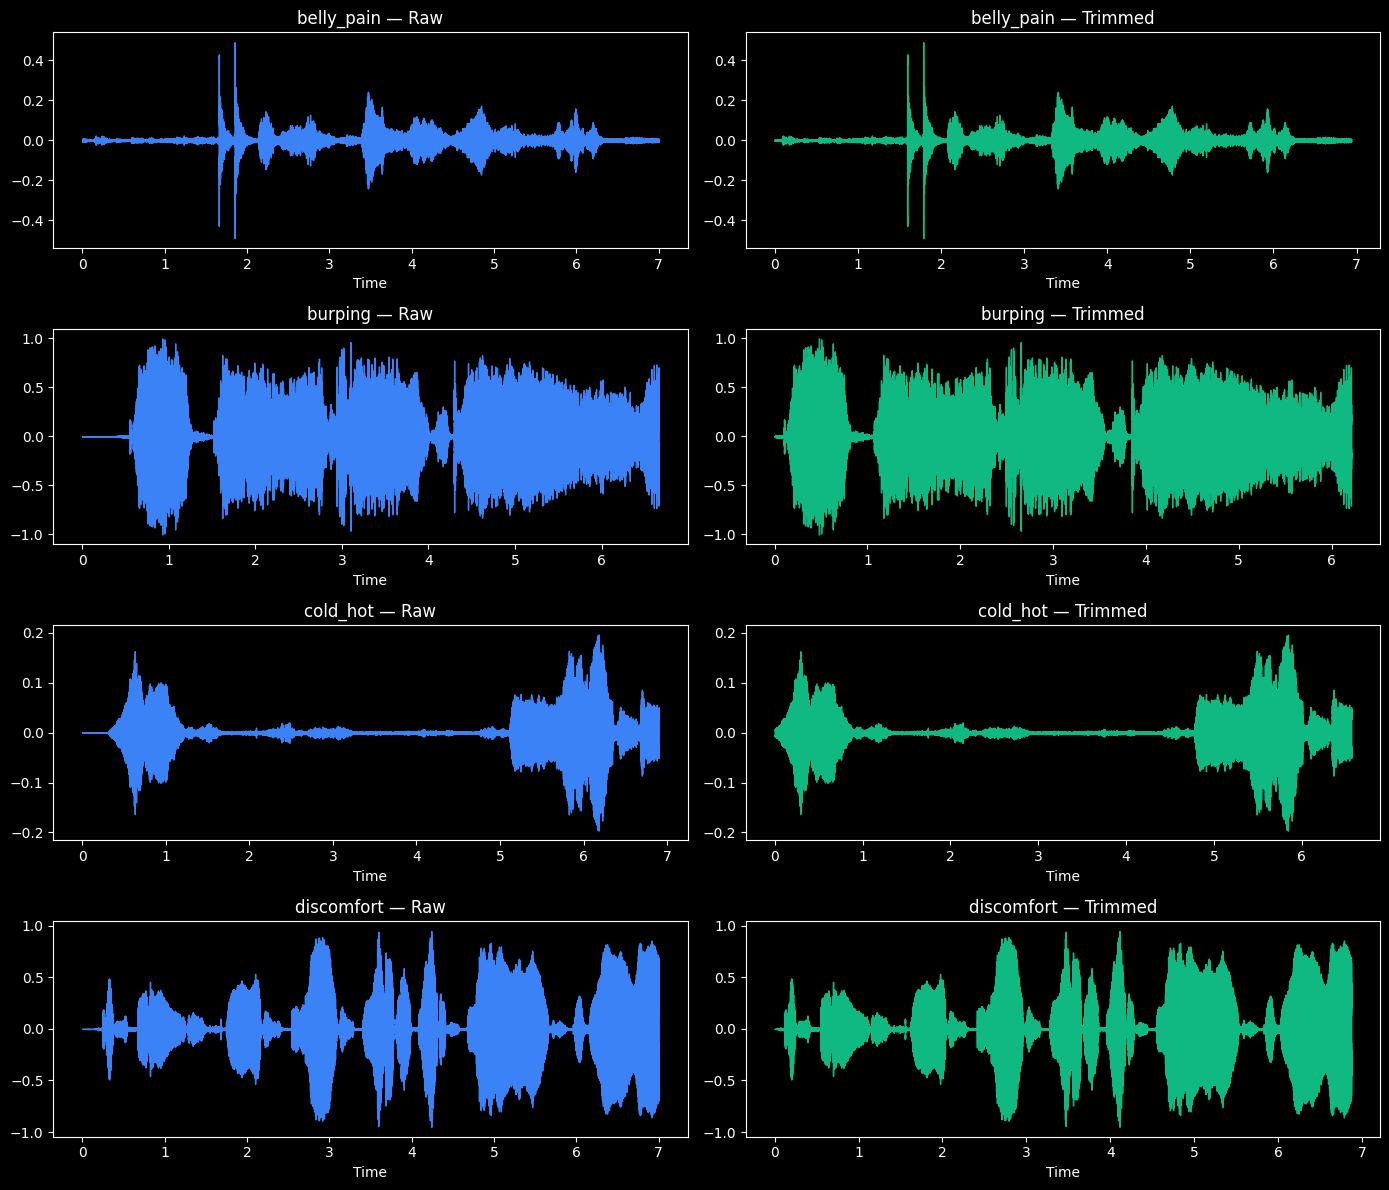

In [94]:
fig, axes = plt.subplots(len(CLASS_FOLDERS[:4]), 2, figsize=(14, 3*len(CLASS_FOLDERS[:4])))
for i, label in enumerate(CLASS_FOLDERS[:4]):
    fp = df_metadata[df_metadata['label']==label]['filepath'].iloc[0]
    y_raw, sr = librosa.load(fp, sr=None)
    y_trim, _ = librosa.effects.trim(y_raw, top_db=30)
    librosa.display.waveshow(y_raw, sr=sr, ax=axes[i][0], color='#3b82f6')
    axes[i][0].set_title(f'{label} — Raw')
    librosa.display.waveshow(y_trim, sr=sr, ax=axes[i][1], color='#10b981')
    axes[i][1].set_title(f'{label} — Trimmed')
plt.tight_layout()
plt.savefig('week1_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

#Cell 5 — Build df_clean

In [95]:
corrupt_names = {e['filename'] for e in error_files}
bad_names = corrupt_names | set(df_dur[~df_dur['usable']]['filename']) | \
            set(df_dur[df_dur['silence_percent'] > 80]['filename'])

df_clean = df_metadata[~df_metadata['filename'].isin(bad_names)].reset_index(drop=True)

print(f"Original: {len(df_metadata)}  →  Clean: {len(df_clean)}")
print(df_clean['label'].value_counts().to_string())

Original: 512  →  Clean: 511
label
hungry        381
discomfort     30
tired          28
scared         20
burping        18
belly_pain     16
lonely         11
cold_hot        7


#Raw Feature Families (MFCC + Repo-Inspired: Chroma, Mel, Contrast, Tonnetz)

#Cell 6 — Raw MFCC Matrix

Raw MFCC shape: (20, 702)  (coefficients × time frames)


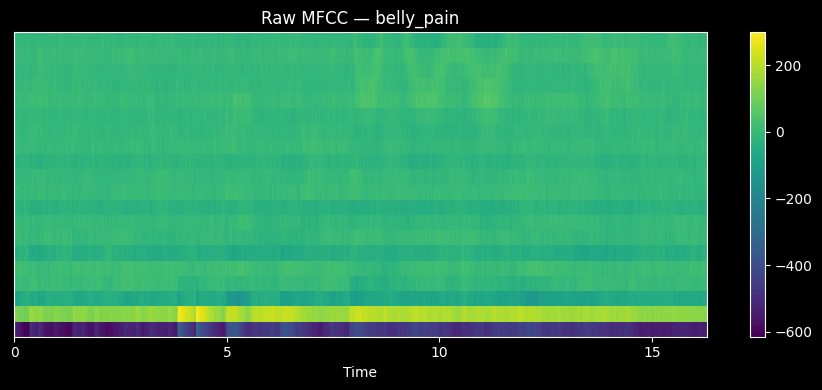

In [96]:
test_label = CLASS_FOLDERS[0]
test_fp = df_clean[df_clean['label']==test_label]['filepath'].iloc[0]
y, sr = librosa.load(test_fp, sr=CONFIG['sample_rate'])

mfcc_raw = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CONFIG['n_mfcc'],
                                 n_fft=CONFIG['n_fft'], hop_length=CONFIG['hop_length'],
                                 win_length=CONFIG['win_length'])
print(f"Raw MFCC shape: {mfcc_raw.shape}  (coefficients × time frames)")

plt.figure(figsize=(9,4))
librosa.display.specshow(mfcc_raw, x_axis='time', sr=sr, cmap='viridis')
plt.colorbar(); plt.title(f'Raw MFCC — {test_label}')
plt.tight_layout(); plt.show()

#Cell 7 — Chroma, Mel-Spectrogram, Spectral Contrast, Tonnetz (Repo-Inspired)

Chroma: (12, 702)  Mel: (40, 702)  Contrast: (8, 702)  Tonnetz: (6, 702)


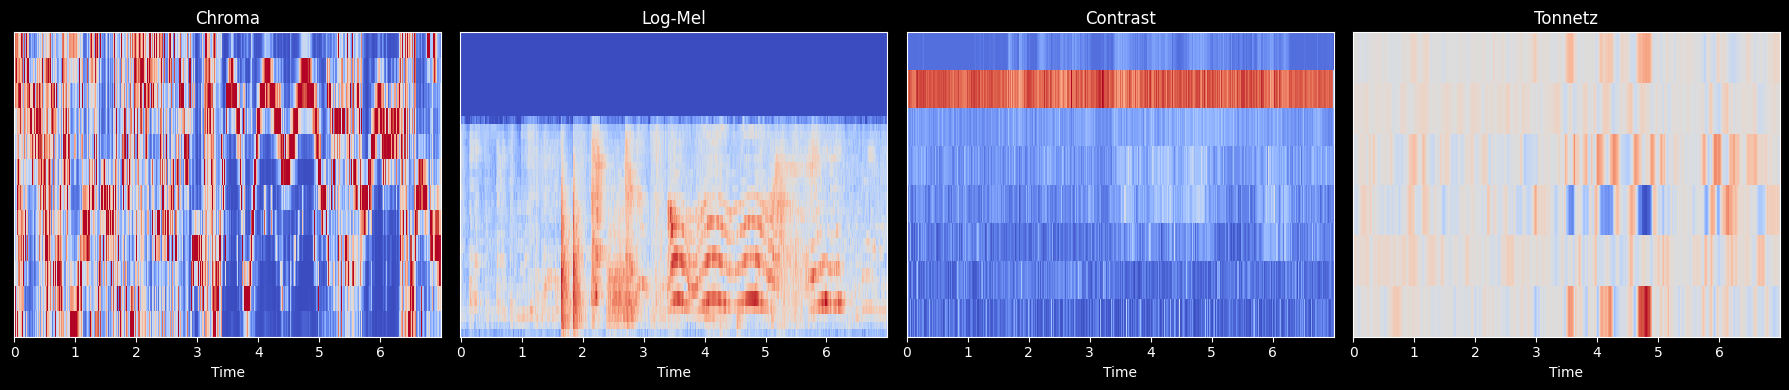

In [97]:
HOP, WIN, NFFT = CONFIG['hop_length'], CONFIG['win_length'], CONFIG['n_fft']

# Chroma — pitch class content
chroma_raw = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=NFFT, hop_length=HOP,
                                          win_length=WIN, n_chroma=12)

# Mel-Spectrogram (log scale) — n_mels=40, NOT 128 (dataset chhota hai, dimensionality control)
mel_raw = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=NFFT, hop_length=HOP,
                                          win_length=WIN, n_mels=40)
log_mel_raw = librosa.power_to_db(mel_raw, ref=np.max)

# Spectral Contrast
contrast_raw = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=NFFT, hop_length=HOP,
                                                  win_length=WIN, n_bands=7, fmin=100)

# Tonnetz
chroma_cqt_raw = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=HOP, n_chroma=12)
tonnetz_raw = librosa.feature.tonnetz(chroma=chroma_cqt_raw)

print(f"Chroma: {chroma_raw.shape}  Mel: {log_mel_raw.shape}  "
      f"Contrast: {contrast_raw.shape}  Tonnetz: {tonnetz_raw.shape}")

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, mat, title in zip(axes, [chroma_raw, log_mel_raw, contrast_raw, tonnetz_raw],
                           ['Chroma', 'Log-Mel', 'Contrast', 'Tonnetz']):
    librosa.display.specshow(mat, sr=sr, hop_length=HOP, x_axis='time', ax=ax, cmap='coolwarm')
    ax.set_title(title)
plt.tight_layout(); plt.savefig('week2_features.png', dpi=150, bbox_inches='tight'); plt.show()

In [98]:
#Cell - 8
def aggregate_features(feature_matrix):
    """2D (n_coeff, time_frames) → 1D (n_coeff*2,) — mean + std per coefficient"""
    mean_vec = np.mean(feature_matrix, axis=1)
    std_vec  = np.std(feature_matrix, axis=1)
    return np.concatenate([mean_vec, std_vec])

test_agg = aggregate_features(mfcc_raw)
print(f"Before: {mfcc_raw.shape}  →  After: {test_agg.shape}")

Before: (20, 702)  →  After: (40,)


#Full Feature Extraction + Master CSV

#Cell 9 — extract_features() (Full — MFCC+Delta+ZCR+Centroid+RMS+Chroma+Mel+Contrast+Tonnetz)

In [99]:
def extract_features(filepath):
    """
    218 features total:
    MFCC(40) + Delta-MFCC(40) + ZCR(2) + Centroid(2) + RMS(2)
    + Chroma(24) + Mel(80) + Contrast(16) + Tonnetz(12)
    """
    y, sr = librosa.load(filepath, sr=CONFIG['sample_rate'])
    y, _ = librosa.effects.trim(y, top_db=30)
    max_amp = np.max(np.abs(y))
    if max_amp > 0:
        y = y / max_amp

    HOP, WIN, NFFT = CONFIG['hop_length'], CONFIG['win_length'], CONFIG['n_fft']
    feats = []

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CONFIG['n_mfcc'], n_fft=NFFT, hop_length=HOP, win_length=WIN)
    feats.append(aggregate_features(mfcc))
    feats.append(aggregate_features(librosa.feature.delta(mfcc)))
    feats.append(aggregate_features(librosa.feature.zero_crossing_rate(y)))
    feats.append(aggregate_features(librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=NFFT, hop_length=HOP)))
    feats.append(aggregate_features(librosa.feature.rms(y=y)))

    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=NFFT, hop_length=HOP, win_length=WIN, n_chroma=12)
    feats.append(aggregate_features(chroma))

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=NFFT, hop_length=HOP, win_length=WIN, n_mels=40)
    feats.append(aggregate_features(librosa.power_to_db(mel, ref=np.max)))

    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=NFFT, hop_length=HOP, win_length=WIN, n_bands=7, fmin=100)
    feats.append(aggregate_features(contrast))

    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=HOP, n_chroma=12)
    feats.append(aggregate_features(librosa.feature.tonnetz(chroma=chroma_cqt)))

    return np.concatenate(feats)

test_vec = extract_features(df_clean['filepath'].iloc[0])
print(f"Feature vector length: {test_vec.shape[0]}  |  NaNs: {np.isnan(test_vec).any()}")

Feature vector length: 218  |  NaNs: False


#Cell 10 — Loop + Build CSV

In [100]:
all_features, all_labels, failed = [], [], []

for idx, row in df_clean.iterrows():
    try:
        feat = extract_features(row['filepath'])
        if np.isnan(feat).any():
            failed.append(row['filename']); continue
        all_features.append(feat)
        all_labels.append(row['label'])
        if len(all_features) % 30 == 0:
            print(f"  {len(all_features)}/{len(df_clean)} done...")
    except Exception as e:
        failed.append(row['filename'])

X = np.array(all_features)
y_labels = np.array(all_labels)

col_names = ([f'mfcc_m{i}' for i in range(20)] + [f'mfcc_s{i}' for i in range(20)] +
             [f'dmfcc_m{i}' for i in range(20)] + [f'dmfcc_s{i}' for i in range(20)] +
             ['zcr_m','zcr_s','cent_m','cent_s','rms_m','rms_s'] +
             [f'chroma_m{i}' for i in range(12)] + [f'chroma_s{i}' for i in range(12)] +
             [f'mel_m{i}' for i in range(40)] + [f'mel_s{i}' for i in range(40)] +
             [f'contrast_m{i}' for i in range(8)] + [f'contrast_s{i}' for i in range(8)] +
             [f'tonnetz_m{i}' for i in range(6)] + [f'tonnetz_s{i}' for i in range(6)])

assert len(col_names) == X.shape[1], f"Mismatch: {len(col_names)} vs {X.shape[1]}"

df_features = pd.DataFrame(X, columns=col_names)
df_features['label'] = y_labels
df_features.to_csv(CONFIG['csv_save_path'], index=False)

print(f"✅ Saved {df_features.shape} to {CONFIG['csv_save_path']}")
print("\n✅ WEEK 4 COMPLETE")

  30/511 done...
  60/511 done...
  90/511 done...
  120/511 done...
  150/511 done...
  180/511 done...
  210/511 done...
  240/511 done...
  270/511 done...
  300/511 done...
  330/511 done...
  360/511 done...
  390/511 done...
  420/511 done...
  450/511 done...
  480/511 done...
  510/511 done...
✅ Saved (511, 219) to /content/drive/MyDrive/Baby Cry Sence Dataset/features_matrix.csv

✅ WEEK 4 COMPLETE


#Cell 11 — Class Distribution

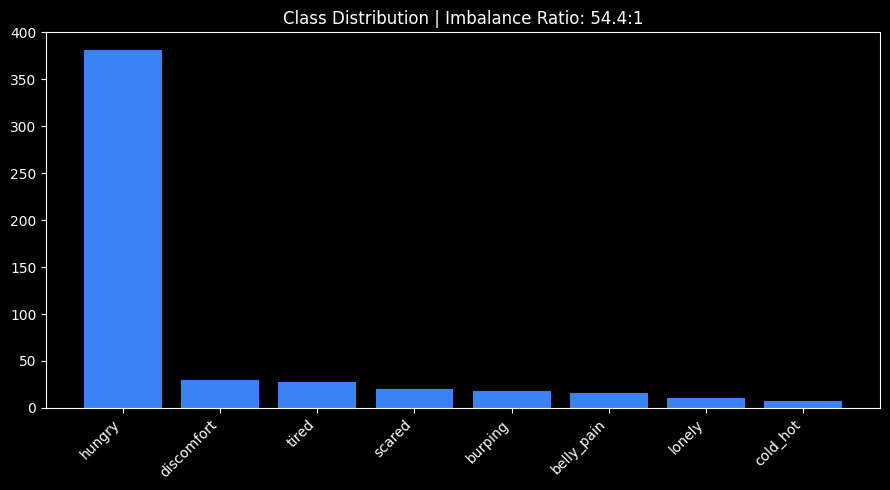

label
hungry        381
discomfort     30
tired          28
scared         20
burping        18
belly_pain     16
lonely         11
cold_hot        7


In [101]:
df_ml = pd.read_csv(CONFIG['csv_save_path'])
counts = df_ml['label'].value_counts()
imbalance_ratio = counts.max() / counts.min()

plt.figure(figsize=(9,5))
plt.bar(counts.index, counts.values, color='#3b82f6')
plt.title(f'Class Distribution | Imbalance Ratio: {imbalance_ratio:.1f}:1')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('week5_distribution.png', dpi=150); plt.show()
print(counts.to_string())

#Cell 12 — Stratified Split + Scale (No Leakage)

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

X_full = df_ml.drop(columns=['label']).values
y_full = df_ml['label'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y_full)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY train
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Train: 408  Test: 103


#Cell 13 — Cost-Sensitive Weights

In [103]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = np.unique(y_train)
weights = compute_class_weight('balanced', classes=class_labels, y=y_train)
class_weight_dict = dict(zip(class_labels, weights))

for code, w in sorted(class_weight_dict.items(), key=lambda x:-x[1]):
    print(f"  {le.classes_[code]:<14}: weight={w:.2f}")

  cold_hot      : weight=8.50
  lonely        : weight=5.67
  belly_pain    : weight=3.92
  burping       : weight=3.64
  scared        : weight=3.19
  tired         : weight=2.32
  discomfort    : weight=2.12
  hungry        : weight=0.17


#Cell 14 — Random Forest (Cost-Sensitive)

In [104]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight=class_weight_dict,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rf = cross_val_score(rf, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"CV F1-Macro: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print(f"\nAccuracy: {accuracy_score(y_test,y_pred_rf)*100:.2f}%  F1 Macro: {f1_score(y_test,y_pred_rf,average='macro',zero_division=0)*100:.2f}%")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

CV F1-Macro: 0.309 ± 0.060

Accuracy: 81.55%  F1 Macro: 32.04%
              precision    recall  f1-score   support

  belly_pain       0.00      0.00      0.00         3
     burping       1.00      0.75      0.86         4
    cold_hot       0.00      0.00      0.00         1
  discomfort       0.00      0.00      0.00         6
      hungry       0.83      1.00      0.91        77
      lonely       0.00      0.00      0.00         2
      scared       0.67      1.00      0.80         4
       tired       0.00      0.00      0.00         6

    accuracy                           0.82       103
   macro avg       0.31      0.34      0.32       103
weighted avg       0.68      0.82      0.74       103

